In [ ]:
# pip install h5py

In [7]:
#Library imports
import h5py
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [13]:
relative_path = '../data/new_Input_CP_Studies_llqq_LinearTerm_29_September2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])
    df_2d = f['LargeRJet']['2d'][:]

In [49]:
relative_path = '../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])
    # df_2d = f['LargeRJet']['2d'][:]

In [42]:
df.columns

Index(['EventNumber', 'FJ_E', 'FJ_eta', 'FJ_flavour', 'FJ_mass', 'FJ_pT',
       'FJ_phi', 'LeadingSubJet_E', 'LeadingSubJet_Eta', 'LeadingSubJet_Phi',
       'LeadingSubJet_pT', 'Lep_pT_balance', 'Lumi_weight', 'NegLep_E',
       'NegLep_Eta', 'NegLep_Phi', 'NegLep_pT', 'Phi', 'Phi1', 'PosLep_E',
       'PosLep_Eta', 'PosLep_Phi', 'PosLep_pT', 'SubLeadingSubJet_E',
       'SubLeadingSubJet_Eta', 'SubLeadingSubJet_Phi', 'SubLeadingSubJet_pT',
       'Type', 'Vlep_E', 'Vlep_eta', 'Vlep_mass', 'Vlep_pT', 'Vlep_phi',
       'cosThetaStar', 'costheta1', 'costheta2'],
      dtype='object')

In [50]:
features_to_drop = ['EventNumber', 'FJ_flavour', 'Lumi_weight','FJ_eta','LeadingSubJet_Phi',
                        'FJ_pT','NegLep_E','LeadingSubJet_E','LeadingSubJet_Eta','PosLep_Eta',
                        'SubLeadingSubJet_E','SubLeadingSubJet_Phi','PosLep_pT','PosLep_Phi','Type',
                        'SubLeadingSubJet_pT','Vlep_E','Vlep_eta','Vlep_pT','Vlep_mass','cosThetaStar',
                        'costheta2']
print(len(features_to_drop),len(df.columns))
df = df.drop(columns= ['Lumi_weight','EventNumber','FJ_flavour'])
df.columns

22 36


Index(['FJ_E', 'FJ_eta', 'FJ_mass', 'FJ_pT', 'FJ_phi', 'LeadingSubJet_E',
       'LeadingSubJet_Eta', 'LeadingSubJet_Phi', 'LeadingSubJet_pT',
       'Lep_pT_balance', 'NegLep_E', 'NegLep_Eta', 'NegLep_Phi', 'NegLep_pT',
       'Phi', 'Phi1', 'PosLep_E', 'PosLep_Eta', 'PosLep_Phi', 'PosLep_pT',
       'SubLeadingSubJet_E', 'SubLeadingSubJet_Eta', 'SubLeadingSubJet_Phi',
       'SubLeadingSubJet_pT', 'Type', 'Vlep_E', 'Vlep_eta', 'Vlep_mass',
       'Vlep_pT', 'Vlep_phi', 'cosThetaStar', 'costheta1', 'costheta2'],
      dtype='object')

In [29]:
df.shape

(546429, 36)

In [32]:
print(sum(df['EventNumber']%2 == 0))
print(sum(df['EventNumber']%2 == 1))

272773
273656


In [56]:
feature_rank_csv = '../data/feature_importances.csv' 
feature_ranking = pd.read_csv(feature_rank_csv)
# print(feature_ranking)

# feature_ranking = feature_ranking[feature_ranking['Importance'] == 0]
print(feature_ranking)
# feature_ranking
# feature_ranking = feature_ranking.sort_values(by='Importance', ascending=False)

    Unnamed: 0               Feature  Importance
0            4                FJ_phi    0.002507
1           32             costheta2    0.002039
2            9        Lep_pT_balance    0.001445
3            6     LeadingSubJet_Eta    0.001171
4           25                Vlep_E    0.001018
5           21  SubLeadingSubJet_Eta    0.000995
6            8      LeadingSubJet_pT    0.000937
7           12            NegLep_Phi    0.000928
8           19             PosLep_pT    0.000912
9            1                FJ_eta    0.000789
10          20    SubLeadingSubJet_E    0.000723
11          26              Vlep_eta    0.000699
12          27             Vlep_mass    0.000550
13          13             NegLep_pT    0.000530
14          22  SubLeadingSubJet_Phi    0.000461
15          14                   Phi    0.000167
16           5       LeadingSubJet_E    0.000147
17          16              PosLep_E    0.000132
18          23   SubLeadingSubJet_pT    0.000121
19           0      

In [26]:
print(df_2d[18])

[(0.        , -0.        , -5.4367399e-01,  1., -0.543674  ,  0., -2.947915  ,   8.780609 )
 (0.        , -0.        , -5.1326442e-01,  1., -0.5132644 ,  0., -2.8929775 ,  75.08305  )
 (0.        , -0.        , -5.2122325e-01, -1., -0.52122325,  0., -2.9068642 ,  10.678407 )
 (0.        , -0.        , -5.1131153e-01, -1., -0.51131153,  0., -2.8768053 ,   5.830158 )
 (0.        , -0.        , -5.0379080e-01,  1., -0.5037908 ,  0., -2.9102607 ,  29.717175 )
 (0.        , -0.        , -5.1306057e-01, -1., -0.51306057,  0., -2.8527308 ,   4.726261 )
 (0.        , -0.        , -5.7618207e-01, -1., -0.57618207,  0., -2.73097   ,   1.2998723)
 (0.        , -0.        , -4.6139029e-01,  1., -0.4613903 ,  0., -2.909247  ,   5.221286 )
 (0.        , -0.        , -4.2682290e-01,  1., -0.4268229 ,  0., -2.980263  ,   2.4458377)
 (0.        , -0.        , -4.8050177e-01, -1., -0.48050177,  0., -2.8038223 ,   2.04067  )
 (0.        , -0.        , -3.4272376e-01,  1., -0.34272376,  0., -2.515001  ,  

In [14]:
df.columns

Index(['FJ_E', 'FJ_eta', 'FJ_flavour', 'FJ_mass', 'FJ_pT', 'FJ_phi',
       'LeadingSubJet_E', 'LeadingSubJet_Eta', 'LeadingSubJet_Phi',
       'LeadingSubJet_pT', 'Lep_pT_balance', 'Lumi_weight', 'NegLep_E',
       'NegLep_Eta', 'NegLep_Phi', 'NegLep_pT', 'Phi', 'Phi1', 'PosLep_E',
       'PosLep_Eta', 'PosLep_Phi', 'PosLep_pT', 'SubLeadingSubJet_E',
       'SubLeadingSubJet_Eta', 'SubLeadingSubJet_Phi', 'SubLeadingSubJet_pT',
       'Type', 'Vlep_E', 'Vlep_eta', 'Vlep_mass', 'Vlep_pT', 'Vlep_phi',
       'cosThetaStar', 'costheta1', 'costheta2'],
      dtype='object')

In [15]:
df.std()

FJ_E                      338.838745
FJ_eta                      1.033157
FJ_flavour                  0.000000
FJ_mass                    23.635305
FJ_pT                     164.491058
FJ_phi                      1.805541
LeadingSubJet_E           292.033844
LeadingSubJet_Eta           1.022548
LeadingSubJet_Phi           1.804583
LeadingSubJet_pT          158.917892
Lep_pT_balance              0.250998
Lumi_weight             11843.583008
NegLep_E                  280.835907
NegLep_Eta                  1.069455
NegLep_Phi                  1.821725
NegLep_pT                 140.904266
Phi                         1.729428
Phi1                        1.797436
PosLep_E                  276.855896
PosLep_Eta                  1.052808
PosLep_Phi                  1.823817
PosLep_pT                 141.759430
SubLeadingSubJet_E        121.004097
SubLeadingSubJet_Eta        1.031425
SubLeadingSubJet_Phi        1.778457
SubLeadingSubJet_pT        59.589146
Type                        0.000000
V

In [ ]:
df.keys()

# Data Key Index:

## Leading index:

FJ: Fat Jet

LeadingSubJet: Smaller jet found within Fat Jet

NegLep, PosLep: Negative and Positively charged leptons

Vlep: reconstructed vector bosons (Z) that decay leptonically

## Secondary Index
E: Energy

Eta: Pseudorapidity

Phi: Azimuthal Angle

pT: transverse momentum

flavour: flavour of quark that initiated jet

mass: invariant mass 

## Extra
Leg_pT_balance: lepton transverse momentum balance

Lumi_weight: luminosity (used for determining signal vs background)

phi: Unsure

phi1: unsure

costhetastar: cosine of decay product in decaying particle frame

costheta1: unsure

costheta2: unsure

In [ ]:
df.Lumi_weight

In [ ]:
X = df.drop(columns=['Lumi_weight'])
y = df['Lumi_weight']

In [ ]:
y

In [ ]:
df.describe()

In [ ]:
zero_mi_features = [
 'FJ_eta', 'LeadingSubJet_pT', 'LeadingSubJet_Phi', 'NegLep_pT', 'Lep_pT_balance',
 'NegLep_Eta', 'NegLep_Phi', 'FJ_mass', 'LeadingSubJet_Eta', 'SubLeadingSubJet_E',
 'PosLep_Eta', 'SubLeadingSubJet_Eta', 'PosLep_Phi', 'PosLep_pT', 'Vlep_E',
 'Vlep_mass', 'cosThetaStar', 'costheta1', 'costheta2'
]

In [ ]:
data_zero = df[zero_mi_features]
data_zero.std()

In [ ]:
scaled_data = (X - X.mean()) / X.std()

In [ ]:
f = plt.figure(figsize=(19, 15))
plt.matshow(scaled_data.corr(), fignum=f.number)
plt.xticks(range(scaled_data.select_dtypes(['number']).shape[1]), scaled_data.select_dtypes(['number']).columns, fontsize=14, rotation=45)
plt.yticks(range(scaled_data.select_dtypes(['number']).shape[1]), scaled_data.select_dtypes(['number']).columns, fontsize=14)
cb = plt.colorbar()
cb.ax.tick_params(labelsize=14)
plt.title('Correlation Matrix', fontsize=16);

In [ ]:
y[y>0] = 1
y[y<0] = 0

In [ ]:
print("Number of signal events:", sum(y==1))
print("Number of background events:", sum(y==0))

In [ ]:
y = np.array(y)

# New dataset exploration


In [61]:
relative_path = '../data/new_Input_CP_Studies_llqq_LinearTerm_13th_October2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])
    df_gen = pd.DataFrame(f['LargeRJet'])
    df_2d = f['LargeRJet']['2d'][:]

In [ ]:
df.shape

In [ ]:
df_2d.shape

In [62]:
df_2d.dtype.names

('constituent_D0',
 'constituent_DZ',
 'constituent_E',
 'constituent_charge',
 'constituent_eta',
 'constituent_isLep',
 'constituent_phi',
 'constituent_pt')

In [ ]:
df_2d['constituent_D0'].ravel()

In [ ]:
df_2d

In [ ]:
df_2d.dtype.names

In [ ]:
n_samples, n_constituents = df_2d.shape
flat_data = {name: df_2d[name].ravel() for name in df_2d.dtype.names}

df_flat = pd.DataFrame(flat_data)

index = pd.MultiIndex.from_product([range(n_samples), range(n_constituents)], names=['sample', 'constituent'])
df_flat.index = index

print(df_flat.head())

In [ ]:
df_flat.shape

In [ ]:
df_gen.head()

In [ ]:
df.columns

In [ ]:
labels = df['Lumi_weight'].values
labels[labels > 0] = 1
labels[labels < 0] = 0

In [ ]:

def structured_to_unstructured(arr):
    #Shape: (n_events, max_constituents, n_features) -> (218023, 60, 8), Convert to 3d array
    new_arr = np.zeros(arr.shape + (len(arr.dtype.names),), dtype=np.float32)
    for i, name in enumerate(arr.dtype.names):
        new_arr[..., i] = arr[name]
    return new_arr


In [ ]:
constituent_features = structured_to_unstructured(df_2d)

In [ ]:
constituent_features.shape

In [ ]:
valid_constituent_mask = constituent_features[:, :, -1] > 0
constituent_features = np.nan_to_num(constituent_features, nan=0.0)

In [ ]:
print(f"Constituent feature shape: {constituent_features.shape}")
print(f"Number of events: {len(labels)}")

In [ ]:
constituent_features

In [ ]:
path = '../graphdata/gnn_discriminant_scores_validation.npz'
data = np.load(path)
discriminant_scores = data['discriminant_scores']
y_true = data['y_true']
y_pred = data['y_pred']
lumi_weights = data['lumi_weights']

In [ ]:
trues = np.sum(y_true)
print('number of true positive labels: ' +str(trues) )
print('number of true negative labels: ' +str(len(y_true)-trues) )

In [ ]:
trues = np.sum(y_pred)
print('number of predicted positive labels: ' +str(trues) )
print('number of predicted negative labels: ' +str(len(y_pred)-trues) )

In [ ]:
print(np.unique(discriminant_scores, return_counts=True)) #Predicting same disciminants for all GNN? is it only considering 1 event??

In [ ]:
lumi_weights 

In [ ]:
lumi_bools = lumi_weights > 0

In [ ]:
ylist = list(y_true + lumi_bools)
print(ylist.count(0)) #should be 27262
print(ylist.count(1)) #should be 0
print(ylist.count(2)) #should be 27244

Labels and Lumi weights are corresponding to each other correctly in processed data

In [ ]:
relative_path = '../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])

In [ ]:
df.columns

In [ ]:
train = df[df['EventNumber'] % 2 == 0]
train.columns

In [ ]:
train.shape

In [ ]:
relative_path = '../data/new_Input_CP_Studies_llqq_LinearTerm_13th_October2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])

df.columns

In [ ]:
df.shape

In [ ]:
import h5py
import pandas as pd

In [ ]:
"C:\Users\colel\OneDrive\Documents\UoE_UG\Y4\SH_Project\SH-Project\data\new_Input_CP_Studies_llqq_LinearTerm_13th_October2025.h5"

In [ ]:
relative_path = '../data/new_Input_CP_Studies_llqq_LinearTerm_13th_October2025.h5'
with h5py.File(relative_path) as f:
    data = f['LargeRJet']['2d'][:]

raveled = pd.DataFrame(data['constituent_D0'].ravel())
dropped = raveled.dropna()
print(dropped.shape)
print(raveled.shape)
print(data.shape)
print(data[0])

In [ ]:
print(data.shape)
print(data[0].shape)   
print(data[0][0])

In [ ]:
import numpy as np

In [ ]:
num_events = data.shape[0]
num_nodes_per_event = data.shape[1]
num_features = len(data.dtype.names)

In [ ]:
reshaped_data = data.view(np.float32).reshape(data.shape[0], data.shape[1], num_features)
print(f"Original data dtype: {data.dtype}")
print(f"New data shape: {reshaped_data.shape}")
print(f"New data dtype: {reshaped_data.dtype}")

In [ ]:
feature_names = list(data.dtype.names)
print(feature_names)

In [ ]:
reshaped_data[:,:,feature_names.index('constituent_isLep')][10]

In [ ]:
import torch

In [ ]:
graph_list = []
for i in range(reshaped_data.shape[0]):
    node_features = torch.tensor(reshaped_data[i],dtype = torch.float)
    eta_idx = feature_names.index('constituent_eta')
    phi_idx = feature_names.index('constituent_phi')
    pos = node_features[:, [eta_idx, phi_idx]]
    edge_index = knn_graph(pos, k=6, loop=False)

    graph_label = torch.tensor([labels[i]], dtype=torch.long)
    
    graph_data = Data(
        x=node_features, 
        edge_index=edge_index, 
        y=graph_label,
        feature_names=feature_names
    )

    graph_list.append(graph_data)

In [ ]:
reshaped_data.columns

In [ ]:
relative_path = "../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5"
with h5py.File(relative_path) as f:
    data = pd.DataFrame(f['LargeRJet']['2d'])
data.head()

In [4]:
import h5py
import pandas as pd
import numpy as np

In [16]:
relative_path = '../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5'
with h5py.File(relative_path) as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])

In [17]:
X = df.drop(columns=['Lumi_weight'])
y = df['Lumi_weight'].copy()
y[y>0] = 1
y[y<0] = 0

print("Fraction of signal (label=1):", (y == 1).mean())

Fraction of signal (label=1): 0.4994610461743429


In [18]:
import numpy as np
import pandas as pd
from sklearn.metrics import roc_auc_score

mask = (df['Lumi_weight'] > 0)
for col in df.columns:
    if col not in ['Lumi_weight', 'EventNumber', 'FJ_flavour']:
        auc = roc_auc_score(mask, df[col])
        print(f"{col:20s}: AUC = {auc:.3f}")

FJ_E                : AUC = 0.500
FJ_eta              : AUC = 0.500
FJ_mass             : AUC = 0.499
FJ_pT               : AUC = 0.500
FJ_phi              : AUC = 0.500
LeadingSubJet_E     : AUC = 0.500
LeadingSubJet_Eta   : AUC = 0.500
LeadingSubJet_Phi   : AUC = 0.500
LeadingSubJet_pT    : AUC = 0.500
Lep_pT_balance      : AUC = 0.500
NegLep_E            : AUC = 0.500
NegLep_Eta          : AUC = 0.500
NegLep_Phi          : AUC = 0.500
NegLep_pT           : AUC = 0.500
Phi                 : AUC = 0.499
Phi1                : AUC = 0.491
PosLep_E            : AUC = 0.499
PosLep_Eta          : AUC = 0.501
PosLep_Phi          : AUC = 0.501
PosLep_pT           : AUC = 0.499
SubLeadingSubJet_E  : AUC = 0.499
SubLeadingSubJet_Eta: AUC = 0.500
SubLeadingSubJet_Phi: AUC = 0.501
SubLeadingSubJet_pT : AUC = 0.500
Type                : AUC = 0.500
Vlep_E              : AUC = 0.499
Vlep_eta            : AUC = 0.501
Vlep_mass           : AUC = 0.500
Vlep_pT             : AUC = 0.500
Vlep_phi      

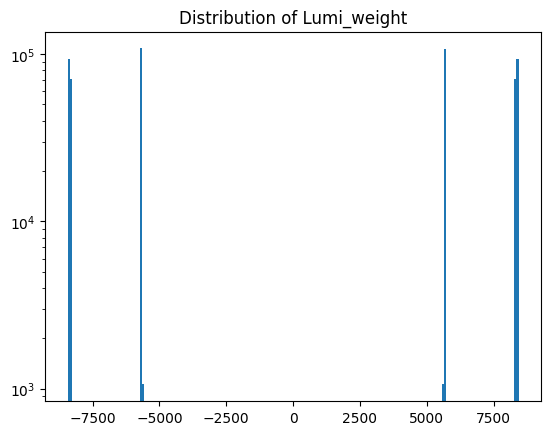

In [19]:
import matplotlib.pyplot as plt
plt.hist(df['Lumi_weight'], bins=200, log=True)
plt.title("Distribution of Lumi_weight")
plt.show()

In [ ]:
train = df[df['EventNumber'] % 2 ==0] # train on even event numbers
test = df[df['EventNumber'] % 2 == 1]

In [ ]:
train.columns

In [ ]:
lumi_train =  train['Lumi_weight'].copy()
lumi_test = test['Lumi_weight'].copy()

y_train = train['Lumi_weight'].copy()
X_train = train.drop(columns=['Lumi_weight','EventNumber'])

y_test = test['Lumi_weight'].copy()
X_test = test.drop(columns=['Lumi_weight','EventNumber'])

y_train[y_train>0] = 1
y_train[y_train<0] = 0

y_test[y_test>0] = 1
y_test[y_test<0] = 0

In [ ]:
print(y_train.value_counts()) #check distribution
print(y_test.value_counts())


In [ ]:
print(lumi_train.head(),'\n', y_train.head()) #check corresponding signs

In [ ]:
train_mean = X_train.mean()
test_mean = X_test.mean()
mean_diff = test_mean - train_mean

In [ ]:
mean_diff

In [ ]:
import numpy as np
data = np.load('../data/dnn_discriminant_scores_20251103.npz')

In [58]:
import h5py
import pandas as pd
import numpy as np
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import StandardScaler, PolynomialFeatures

relative_path = '../data/s2286706/new_Input_CP_Studies_llqq_LinearTerm_20th_October2025.h5'
with h5py.File(relative_path, 'r') as f:
    df = pd.DataFrame(f['LargeRJet']['1d'][:])

In [59]:
X = df.drop(columns=['Lumi_weight', 'EventNumber', 'FJ_flavour','Type'])
y = df['Lumi_weight'].copy()
y[y > 0] = 1
y[y < 0] = 0
y = y.values


In [60]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
feature_names = X.columns.tolist()

In [63]:
len(feature_names)

32

In [64]:
mi_base = mutual_info_classif(X_scaled, y, random_state=42)
base_info = pd.DataFrame({'Feature': feature_names, 'MutualInfo': mi_base})
base_info = base_info.sort_values('MutualInfo', ascending=False)

In [29]:
poly = PolynomialFeatures(degree=2, interaction_only=False, include_bias=False)
X_poly = poly.fit_transform(X_scaled)
# X_poly['pt_ratio'] = df['PosLep_pT'] / (df['NegLep_pT'] + 1e-6)
# X_poly['energy_asymmetry'] = (df['PosLep_E'] - df['NegLep_E']) / (df['PosLep_E'] + df['NegLep_E'] + 1e-6)
poly_features = poly.get_feature_names_out(feature_names)
X['pt_ratio'] = df['PosLep_pT'] / (df['NegLep_pT'] + 1e-6)
X['energy_asymmetry'] = (df['PosLep_E'] - df['NegLep_E']) / (df['PosLep_E'] + df['NegLep_E'] + 1e-6)


In [65]:
mi_poly = mutual_info_classif(X_poly, y, random_state=42)
poly_info = pd.DataFrame({'Feature': poly_features, 'MutualInfo': mi_poly})
poly_info = poly_info.sort_values('MutualInfo', ascending=False)

NameError: name 'X_poly' is not defined

In [66]:
top_base = base_info.head(10)
# top_poly = poly_info.head(10)

display(top_base)
# display(top_poly)

print(f"Total MI (base): {mi_base.sum():.4f}")
# print(f"Total MI (poly): {mi_poly.sum():.4f}")
# print(f"Gain ratio: {mi_poly.sum()/mi_base.sum():.2f}x")

,Feature,MutualInfo
5,LeadingSubJet_E,0.001453
20,SubLeadingSubJet_E,0.001061
18,PosLep_Phi,0.000975
12,NegLep_Phi,0.000759
6,LeadingSubJet_Eta,0.000749
13,NegLep_pT,0.000639
16,PosLep_E,0.000510
21,SubLeadingSubJet_Eta,0.000485
3,FJ_pT,0.000465
8,LeadingSubJet_pT,0.000440


Total MI (base): 0.0089


In [74]:
base_info


,Feature,MutualInfo
5,LeadingSubJet_E,0.001453
20,SubLeadingSubJet_E,0.001061
18,PosLep_Phi,0.000975
12,NegLep_Phi,0.000759
6,LeadingSubJet_Eta,0.000749
13,NegLep_pT,0.000639
16,PosLep_E,0.000510
21,SubLeadingSubJet_Eta,0.000485
3,FJ_pT,0.000465
8,LeadingSubJet_pT,0.000440


In [ ]:
import torch
tensors = torch.load("../data/processed/data_tensors_even.pt")
print("Input size:", tensors["X_train"].shape[1])

Input size: 33


{'X_train': tensor([[ 1.3748e-01,  1.3117e+00,  5.0010e-01,  ..., -8.5149e-01,
          -1.3115e+00, -1.0861e+00],
         [-7.2242e-01, -5.0344e-01,  4.2576e-02,  ...,  1.7024e+00,
           9.7964e-01,  1.6620e+00],
         [ 6.0809e-01,  8.9909e-01,  1.0805e-01,  ..., -7.6167e-01,
           3.9179e-01,  1.2200e-01],
         ...,
         [-2.2593e-01, -7.9936e-01,  1.5973e-01,  ...,  1.3202e+00,
           8.1036e-01,  6.2264e-01],
         [ 6.1892e-01,  1.4764e+00,  1.5904e-01,  ..., -1.2126e+00,
           1.6278e+00, -7.7728e-01],
         [-1.1031e+00, -2.4572e-01, -3.1683e-01,  ..., -5.8080e-02,
           1.1193e-03, -5.8392e-01]]),
 'X_test': tensor([[-0.1100,  0.8526,  0.3616,  ..., -1.2107, -1.0779,  0.3732],
         [-0.6603, -0.2299, -0.1733,  ...,  0.2218,  0.0669, -0.7314],
         [-0.7273,  0.3391, -0.4977,  ...,  1.1821, -0.5423, -0.0265],
         ...,
         [ 0.0942,  0.6181,  3.5255,  ...,  1.2115, -0.9649, -0.5976],
         [-0.2226,  0.8675,  0.3622

In [ ]:
import numpy as np
data = np.load(r"C:\Users\colel\OneDrive\Documents\UoE_UG\Y4\SH_Project\SH-Project\data\dnn_discriminant_scores_20251107_odd.npz")
discriminant_scores = data['discriminant_scores']
print(discriminant_scores.max(),discriminant_scores.min())

0.7770443 -0.28711593


In [15]:
data = np.load('../results/optuna_33_feature.npz')
discriminant_scores = data['discriminant_scores']
print(discriminant_scores.max(),discriminant_scores.min())

0.11332953 -0.021289587


In [35]:
import os
import numpy as np
import pandas as pd
import torch

# -----------------------------
# 1) Choose how many to keep
# -----------------------------
N_BASE = 10     # top-N base features
N_POLY = 30     # top-N engineered (poly/interaction) features

selected_base = base_info.head(N_BASE)['Feature'].tolist()
selected_poly = poly_info.head(N_POLY)['Feature'].tolist()

# Optional: avoid duplicate names if they ever overlap (rare but safe)
selected_poly = [f for f in selected_poly if f not in selected_base]

print(f"Selected {len(selected_base)} base + {len(selected_poly)} poly features")

# -----------------------------
# 2) Build selected feature matrix WITHOUT recomputing MI
# -----------------------------
# Map arrays -> DataFrames to pick by name
X_base_df = pd.DataFrame(X_scaled, columns=feature_names)
X_poly_df = pd.DataFrame(X_poly, columns=poly_features)

# Extract columns and concat
X_sel_base = X_base_df[selected_base] if selected_base else pd.DataFrame(index=X_base_df.index)
X_sel_poly = X_poly_df[selected_poly] if selected_poly else pd.DataFrame(index=X_poly_df.index)

X_selected = pd.concat([X_sel_base, X_sel_poly], axis=1)

# -----------------------------
# 3) (Optional) Add your two custom engineered features you already computed
#     NOTE: These were created on *unscaled* X earlier; to keep consistency, z-score them now.
# -----------------------------
if 'pt_ratio' in X.columns and 'energy_asymmetry' in X.columns:
    from sklearn.preprocessing import StandardScaler
    extra_scaler = StandardScaler()
    extra_scaled = extra_scaler.fit_transform(X[['pt_ratio','energy_asymmetry']])
    extra_df = pd.DataFrame(extra_scaled, columns=['pt_ratio','energy_asymmetry'], index=X.index)
    X_selected = pd.concat([X_selected, extra_df], axis=1)
    print("Added scaled custom features: ['pt_ratio','energy_asymmetry']")

# -----------------------------
# 4) Attach targets/metadata (NOT scaled)
# -----------------------------
lumi = df['Lumi_weight'].to_numpy().astype(np.float32)
event = df['EventNumber'].to_numpy().astype(np.int64)

# -----------------------------
# 5) Save to disk (.pt and .npz)
# -----------------------------
out_dir = '../data/processed'
os.makedirs(out_dir, exist_ok=True)

# PyTorch package (easy drop-in for your training scripts)
tensor_pack = {
    'X': torch.tensor(X_selected.to_numpy(), dtype=torch.float32),
    'y': torch.tensor(y, dtype=torch.long),
    'lumi': torch.tensor(lumi, dtype=torch.float32),
    'event': torch.tensor(event, dtype=torch.long),
    'feature_names': list(X_selected.columns)
}
pt_path = os.path.join(out_dir, f'top_features_{len(X_selected.columns)}.pt')
torch.save(tensor_pack, pt_path)

# NPZ (nice for quick inspection/plotting)
npz_path = os.path.join(out_dir, f'top_features_{len(X_selected.columns)}.npz')
np.savez(
    npz_path,
    X=X_selected.to_numpy().astype(np.float32),
    y=y.astype(np.int64),
    lumi=lumi,
    event=event,
    feature_names=np.array(list(X_selected.columns), dtype=object)
)

print(f"✅ Saved:\n- {pt_path}\n- {npz_path}")
print(f"Final feature count: {X_selected.shape[1]}")

Selected 10 base + 28 poly features
Added scaled custom features: ['pt_ratio','energy_asymmetry']
✅ Saved:
- ../data/processed\top_features_40.pt
- ../data/processed\top_features_40.npz
Final feature count: 40


In [49]:
data= np.load('../data/processed/top_features_40.npz')
data.keys()

KeysView(NpzFile '../data/processed/top_features_40.npz' with keys: X, y, lumi, event, feature_names)

In [50]:
base_info = pd.DataFrame({'Feature': feature_names, 'MutualInfo': mi_base})
poly_info = pd.DataFrame({'Feature': poly_features, 'MutualInfo': mi_poly})

In [56]:
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.size": 12,
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "axes.linewidth": 1.2,
    "xtick.major.size": 5,
    "ytick.major.size": 5,
})


In [57]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Sort descending for plotting
base_info_sorted = base_info.sort_values("MutualInfo", ascending=False).reset_index(drop=True)
poly_info_sorted = poly_info.sort_values("MutualInfo", ascending=False).reset_index(drop=True)

# Optional: normalize to show relative strength
base_info_sorted["NormMI"] = base_info_sorted["MutualInfo"] / base_info_sorted["MutualInfo"].max()
poly_info_sorted["NormMI"] = poly_info_sorted["MutualInfo"] / poly_info_sorted["MutualInfo"].max()


C:\Users\colel\AppData\Local\Temp\ipykernel_39236\1761627556.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


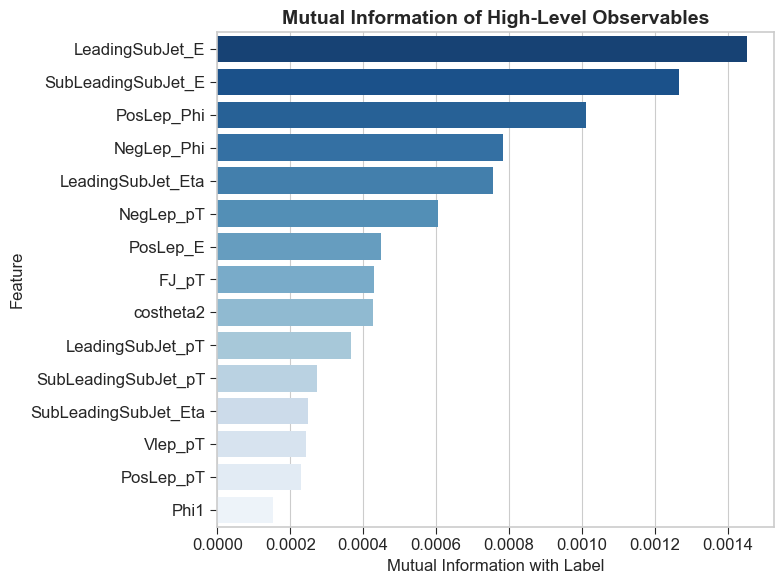

In [58]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=base_info_sorted.head(15),
    x="MutualInfo", y="Feature",
    palette="Blues_r"
)
plt.xlabel("Mutual Information with Label", fontsize=12)
plt.ylabel("Feature", fontsize=12)
plt.title("Mutual Information of High-Level Observables", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig("../plots/MI_highlevel_base.png", dpi=300)
plt.show()


C:\Users\colel\AppData\Local\Temp\ipykernel_39236\2975636825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


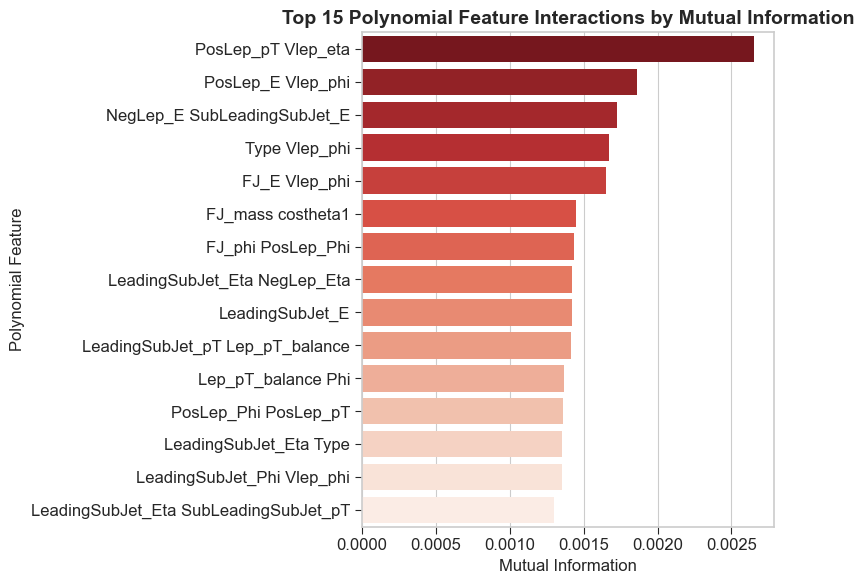

In [59]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=poly_info_sorted.head(15),
    x="MutualInfo", y="Feature",
    palette="Reds_r"
)
plt.xlabel("Mutual Information", fontsize=12)
plt.ylabel("Polynomial Feature", fontsize=12)
plt.title("Top 15 Polynomial Feature Interactions by Mutual Information", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig("../plots/MI_polynomial_features.png", dpi=300)
plt.show()


C:\Users\colel\AppData\Local\Temp\ipykernel_39236\2975636825.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


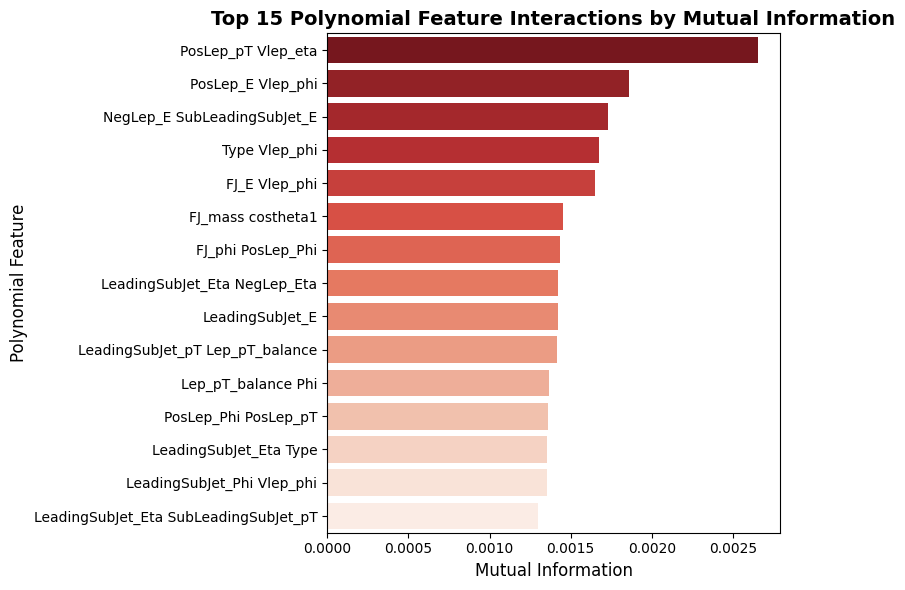

In [54]:
plt.figure(figsize=(8,6))
sns.barplot(
    data=poly_info_sorted.head(15),
    x="MutualInfo", y="Feature",
    palette="Reds_r"
)
plt.xlabel("Mutual Information", fontsize=12)
plt.ylabel("Polynomial Feature", fontsize=12)
plt.title("Top 15 Polynomial Feature Interactions by Mutual Information", fontsize=14, weight='bold')
plt.tight_layout()
plt.savefig("../plots/MI_polynomial_features.png", dpi=300)
plt.show()


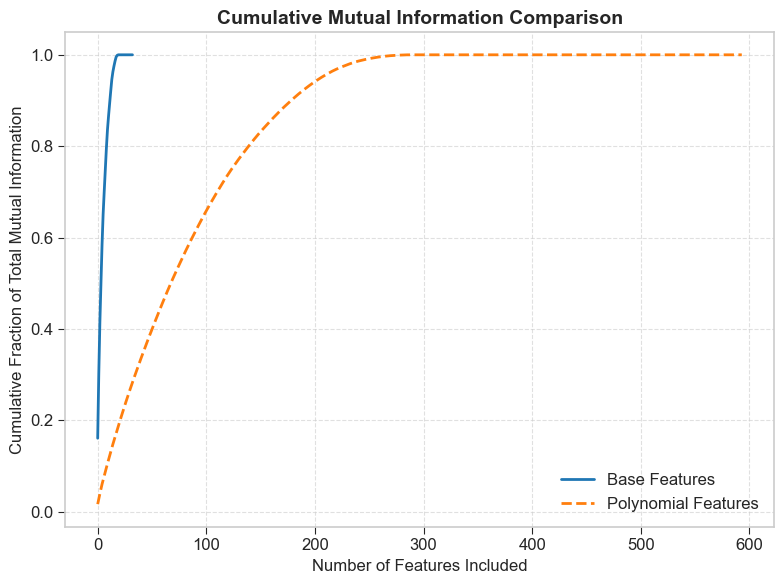

In [60]:
plt.figure(figsize=(8,6))
base_info_sorted['Cumulative'] = base_info_sorted['MutualInfo'].cumsum() / base_info_sorted['MutualInfo'].sum()
plt.plot(range(len(base_info_sorted)), base_info_sorted['Cumulative'], label='Base Features', lw=2)

poly_info_sorted['Cumulative'] = poly_info_sorted['MutualInfo'].cumsum() / poly_info_sorted['MutualInfo'].sum()
plt.plot(range(len(poly_info_sorted)), poly_info_sorted['Cumulative'], label='Polynomial Features', lw=2, linestyle='--')

plt.xlabel("Number of Features Included", fontsize=12)
plt.ylabel("Cumulative Fraction of Total Mutual Information", fontsize=12)
plt.title("Cumulative Mutual Information Comparison", fontsize=14, weight='bold')
plt.legend()
plt.grid(True, linestyle="--", alpha=0.6)
plt.tight_layout()
plt.savefig("../plots/MI_cumulative_comparison.png", dpi=300)
plt.show()


In [64]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("../data/feature_importances.csv")

df.head()

,Unnamed: 0,Feature,Importance
0,4,FJ_phi,0.002507
1,32,costheta2,0.002039
2,9,Lep_pT_balance,0.001445
3,6,LeadingSubJet_Eta,0.001171
4,25,Vlep_E,0.001018


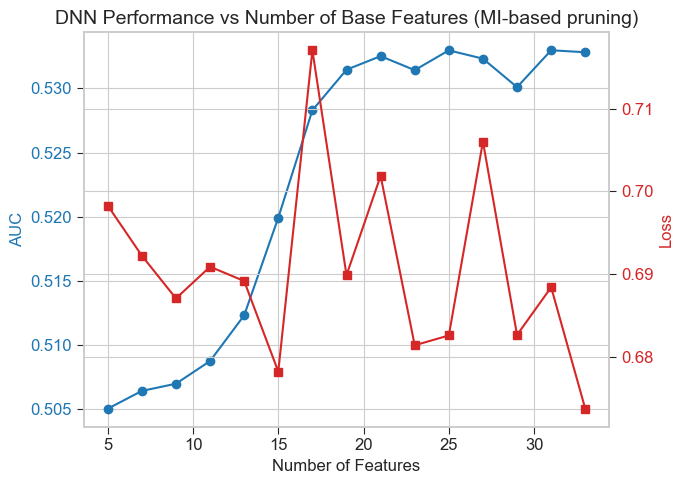

In [65]:
import pandas as pd, matplotlib.pyplot as plt
df = pd.read_csv("../results/feature_pruning_results.csv")

fig, ax1 = plt.subplots(figsize=(7,5))
color = 'tab:blue'
ax1.plot(df["n_features"], df["AUC"], marker='o', color=color)
ax1.set_xlabel("Number of Features")
ax1.set_ylabel("AUC", color=color)
ax1.tick_params(axis='y', labelcolor=color)

ax2 = ax1.twinx()
color = 'tab:red'
ax2.plot(df["n_features"], df["Loss"], marker='s', color=color)
ax2.set_ylabel("Loss", color=color)
ax2.tick_params(axis='y', labelcolor=color)

plt.title("DNN Performance vs Number of Base Features (MI-based pruning)")
plt.tight_layout()
plt.savefig("../plots/DNN_feature_pruning_base.png", dpi=300)
plt.show()
